In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# List all items in the root of MyDrive
os.listdir('/content/drive/MyDrive')

['Database Systems ',
 'Database Administration and Management',
 'Advanced Database Management Systems',
 'Classroom',
 'Database-System-A-Practical-Approach-to-Design-Implementation-and-Management-by-T-Connoly-C-Begg (1).pdf',
 'Database-System-A-Practical-Approach-to-Design-Implementation-and-Management-by-T-Connoly-C-Begg.pdf',
 'Online Demos for Final Project.xlsx',
 'Online Demos for Final Project.gsheet',
 'RDMS_Complete_Project_Report  1.pdf',
 'Invigilation Plan (Amin Campus) - Undergraduate - Final Exam Spring 2026 All Semester.gdoc',
 'Invigilation plan sadam.pdf',
 'Marks Sheet.xlsx',
 'Agentic AI',
 'Grade Award Sheet Sp-26.gsheet',
 'Deep Learning',
 'Colab Notebooks',
 'Programming for AI - AI212']

### Model Training Setup

This section prepares the environment and runs the YOLOv8 model training process. It includes:
1.  **Imports:** Necessary libraries for file operations, YAML parsing, and YOLO model functionality.
2.  **Path Definition:** Adapting the dataset path to the Google Drive environment.
3.  **`data.yaml` Configuration:** Ensuring the dataset configuration file (`data.yaml`) correctly points to the data directories.
4.  **Model Loading:** Loading a pre-trained YOLOv8n model.
5.  **Training:** Executing the model training loop with specified parameters.

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.9 MB/s eta 0:00:00


In [ ]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [ ]:
import os
import yaml
from ultralytics import YOLO

# 1. Define base path for Google Drive
# Adjusted based on your Google Drive content from the previous output.
BASE_DIR = '/content/drive/MyDrive/Deep Learning/Textile Defect Detection'

# Adjust this if you unzipped 'YOLO' directly without the 'FD_Dataset' parent folder
DATASET_YOLO_DIR = os.path.join(BASE_DIR, "FD_Dataset", "YOLO")
yaml_path = os.path.join(DATASET_YOLO_DIR, "data.yaml")

if not os.path.exists(yaml_path):
    # Alternative fallback if extracted directly to the root folder
    DATASET_YOLO_DIR = os.path.join(BASE_DIR, "YOLO")
    yaml_path = os.path.join(DATASET_YOLO_DIR, "data.yaml")

if not os.path.exists(yaml_path):
    raise FileNotFoundError(f"❌ Could not find data.yaml! Verify it exists at: {yaml_path}")

print(f"📦 Dataset located at: {DATASET_YOLO_DIR}")
print(f"🔧 Verifying and updating local paths inside: {yaml_path}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
📦 Dataset located at: /content/drive/MyDrive/Deep Learning/Textile Defect Detection/FD_Dataset/YOLO
🔧 Verifying and updating local paths inside: /content/drive/MyDrive/Deep Learning/Textile Defect Detection/FD_Dataset/YOLO/data.yaml


In [ ]:
# 2. Automatically fix paths inside the downloaded data.yaml file
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f) or {}

# Force absolute paths to prevent Windows background directory confusion
data_config['path'] = DATASET_YOLO_DIR
data_config['train'] = os.path.join("train", "images")
data_config['val'] = os.path.join("valid", "images")
if "test" in os.listdir(DATASET_YOLO_DIR):
    data_config['test'] = os.path.join("test", "images")

# Save corrected configuration mappings back to file
with open(yaml_path, 'w') as f:
    yaml.safe_dump(data_config, f, default_flow_style=False)

print("✓ data.yaml paths verified and updated successfully.")

✓ data.yaml paths verified and updated successfully.


In [ ]:
# 3. Load baseline pre-trained YOLOv8 Nano model weights
model = YOLO("yolov8n.pt")

print("🚀 Initializing Custom Figshare Defect Training Sequence...")

🚀 Initializing Custom Figshare Defect Training Sequence...


In [ ]:
for param in model.parameters():
    print(type(param), param.size())

<class 'torch.nn.parameter.Parameter'> torch.Size([16, 3, 3, 3])
<class 'torch.nn.parameter.Parameter'> torch.Size([16])
<class 'torch.nn.parameter.Parameter'> torch.Size([16])
<class 'torch.nn.parameter.Parameter'> torch.Size([32, 16, 3, 3])
<class 'torch.nn.parameter.Parameter'> torch.Size([32])
<class 'torch.nn.parameter.Parameter'> torch.Size([32])
<class 'torch.nn.parameter.Parameter'> torch.Size([32, 32, 1, 1])
<class 'torch.nn.parameter.Parameter'> torch.Size([32])
<class 'torch.nn.parameter.Parameter'> torch.Size([32])
<class 'torch.nn.parameter.Parameter'> torch.Size([32, 48, 1, 1])
<class 'torch.nn.parameter.Parameter'> torch.Size([32])
<class 'torch.nn.parameter.Parameter'> torch.Size([32])
<class 'torch.nn.parameter.Parameter'> torch.Size([16, 16, 3, 3])
<class 'torch.nn.parameter.Parameter'> torch.Size([16])
<class 'torch.nn.parameter.Parameter'> torch.Size([16])
<class 'torch.nn.parameter.Parameter'> torch.Size([16, 16, 3, 3])
<class 'torch.nn.parameter.Parameter'> torch.

In [ ]:
# 4. Run Model Training Loop
model.train(
    data=yaml_path,
    epochs=50,          # Adjust epochs based on your requirements
    imgsz=640,          # Standard dataset image matrix layout
    batch=16,           # Sizing structure per batch pass
    device=device,           # Use 'cpu' as no GPU is available
    workers=8,          # Increased for Colab's Linux environment
    project=os.path.join(BASE_DIR, "runs"),
    name="figshare_fabric_model"
)

print("\n✓ Training Sequence Completed Successfully!")
print(f"Your fine-tuned weights are saved at: {os.path.join(BASE_DIR, 'runs', 'figshare_fabric_model', 'weights', 'best.pt')}")

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Deep Learning/Textile Defect Detection/FD_Dataset/YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=figshare_fabric_model-5, nbs=64, nms=False

### Custom Model Configuration

To create a custom model with fewer parameters than `yolov8n`, we will define a new YAML configuration file. This file will specify a scaled-down version of the YOLOv8 architecture, which is beneficial for smaller datasets to prevent overfitting and reduce computational cost. The `depth_multiple` and `width_multiple` parameters control the overall depth and width of the model, respectively.

### Model Prediction and Evaluation

This section handles the prediction and evaluation of the trained YOLOv8 model:
1.  **Configuration:** Defines paths for the trained weights and the `data.yaml` file.
2.  **Model Loading:** Loads the `best.pt` weights from the training run.
3.  **Validation:** Performs a validation pass on the dataset to calculate key performance metrics (Precision, Recall, F1-Score, mAP).
4.  **Inference and Visualization:** Runs inference on a sample image from the validation set and overlays bounding box visualizations, then displays and saves the annotated image.

🔄 Loading custom weights: /content/drive/MyDrive/Deep Learning/Textile Defect Detection/runs/figshare_fabric_model-5/weights/best.pt

📊 Step 1/2: Running complete statistical validation pass...
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 2.0±2.3 ms, read: 12.9±9.2 MB/s, size: 71.8 KB)
val: Scanning /content/drive/MyDrive/Deep Learning/Textile Defect Detection/FD_Dataset/YOLO/valid/labels.cache... 73 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73 16.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.0s/it 5.0s
                   all         73         81      0.935      0.877      0.943      0.558
                     0         25         30      0.964      0.887      0.983      0.644
                     1         18         18      0.933      0.944    

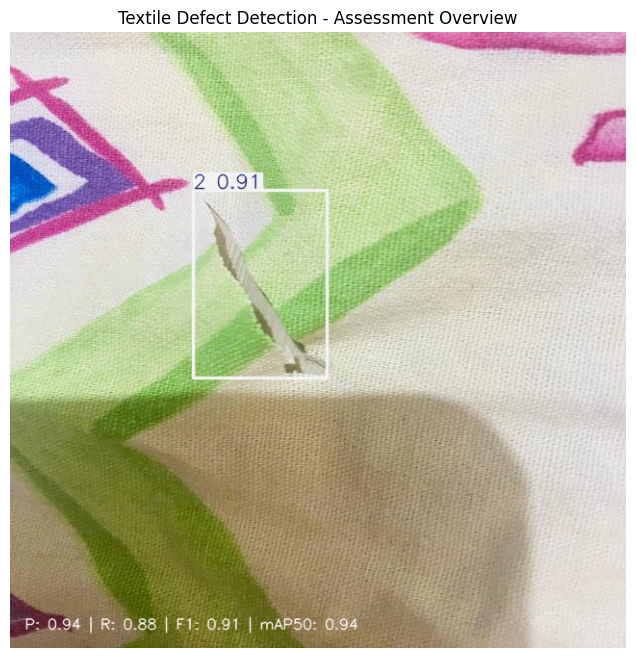

In [ ]:
import os
import cv2
import time
from ultralytics import YOLO
from IPython.display import Image, display
import matplotlib.pyplot as plt

def run_prediction():
    # 1. Base Workspace Configuration Setup
    BASE_DIR = '/content/drive/MyDrive/Deep Learning/Textile Defect Detection'
    weights_path = os.path.join(BASE_DIR, "runs", "figshare_fabric_model-5", "weights", "best.pt")
    yaml_path = os.path.join(BASE_DIR, "FD_Dataset", "YOLO", "data.yaml")
    if not os.path.exists(yaml_path):
        yaml_path = os.path.join(BASE_DIR, "YOLO", "data.yaml")

    # Safety checks
    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"❌ Weights not found at: {weights_path}. Run training first!")
    if not os.path.exists(yaml_path):
        raise FileNotFoundError(f"❌ data.yaml config not found at: {yaml_path}")

    print(f"🔄 Loading custom weights: {weights_path}")
    model = YOLO(weights_path)

    # =========================================================================
    # PHASE 1: GENERATE INDUSTRIAL METRIC ANALYSIS REPORT
    # =========================================================================
    print("\n📊 Step 1/2: Running complete statistical validation pass...")
    metrics = model.val(
        data=yaml_path,
        split='val',
        device='cpu', # Use 'cpu' as no GPU is available
        workers=8, # Increased for Colab's Linux environment
        project=os.path.join(BASE_DIR, "runs"),
        name="evaluation_metrics_run"
    )

    # Mathematical metric extraction
    mean_precision = metrics.box.mp
    mean_recall = metrics.box.mr
    map50 = metrics.box.map50
    map50_95 = metrics.box.map

    if (mean_precision + mean_recall) > 0:
        f1_score = 2 * (mean_precision * mean_recall) / (mean_precision + mean_recall)
    else:
        f1_score = 0.0

    # Print out terminal scorecard ledger
    print("\n" + "="*60)
    print("📈 FABRIC DEFECT DETECTION PERFORMANCE EVALUATION CARD")
    print("="*60)
    print(f"🔹 Precision:   {mean_precision:.4f}  (Ability to avoid false alarms)")
    print(f"🔹 Recall:      {mean_recall:.4f}  (Ability to locate target defects)")
    print(f"🔹 F1-Score:    {f1_score:.4f}  (Balanced harmonic mean benchmark)")
    print(f"🔹 mAP@50:      {map50:.4f}  (Localization metric at 50% box overlap)")
    print(f"🔹 mAP@50-95:   {map50_95:.4f}  (Strict precision bounding box rating)")
    print("="*60)

    # =========================================================================
    # PHASE 2: RUN INFERENCE AND OVERLAY BOUNDING BOX VISUALIZATIONS
    # =========================================================================
    print("\n📷 Step 2/2: Generating visual bounding box tracking layout...")
    valid_images_dir = os.path.join(BASE_DIR, "FD_Dataset", "YOLO", "valid", "images")
    if not os.path.exists(valid_images_dir):
        valid_images_dir = os.path.join(BASE_DIR, "YOLO", "valid", "images")

    if os.path.exists(valid_images_dir) and os.listdir(valid_images_dir):
        sample_img_file = os.listdir(valid_images_dir)[0]
        test_image_file = os.path.join(valid_images_dir, sample_img_file)
    else:
        raise FileNotFoundError(f"❌ Missing target validation images inside: {valid_images_dir}")

    # Re-initialize the model to ensure a clean state before inference
    # And ensure device consistency with the validation step
    print(f"🔄 Re-loading custom weights for inference: {weights_path}")
    model = YOLO(weights_path)

    results = model(test_image_file, device='cpu') # Explicitly set device to 'cpu' for consistency

    if len(results) > 0:
        # Generate the canvas with boxes, tags, and confidence scores automatically
        annotated_frame = results[0].plot() # This returns a NumPy array (BGR format)

        # Convert BGR to RGB for matplotlib display
        annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

        # Write text metrics directly onto the output image window background
        info_banner = f"P: {mean_precision:.2f} | R: {mean_recall:.2f} | F1: {f1_score:.2f} | mAP50: {map50:.2f}"
        cv2.putText(annotated_frame_rgb, info_banner, (15, annotated_frame_rgb.shape[0] - 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

        # Save result to file
        output_dir = os.path.join(BASE_DIR, "runs")
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, "evaluation_visual_output.jpg")
        cv2.imwrite(output_path, annotated_frame)
        print(f"✓ Visual annotated frame successfully saved to: {output_path}")

        # Display result via Matplotlib in Colab
        plt.figure(figsize=(10, 8))
        plt.imshow(annotated_frame_rgb)
        plt.title("Textile Defect Detection - Assessment Overview")
        plt.axis('off')
        plt.show()
    else:
        print("⚠️ No detection coordinates found to overlay onto target fabric file sample.")

run_prediction()

**Custom Model Configurations**

In [ ]:
# import os

# # Define content for a custom, even smaller YOLOv8 model YAML
# # This is a scaled-down version of yolov8n.yaml, reducing depth and width.
# custom_model_yaml_content = """
# # YOLOv8-Custom-Tiny model
# # Parameters
# nc: 80  # number of classes
# depth_multiple: 0.25  # model depth multiple
# width_multiple: 0.25  # layer channel multiple
# """

# # You would typically find the full yolov8n.yaml content in ultralytics/cfg/models/v8/yolov8n.yaml
# # For simplicity and demonstrating a custom, smaller model, we're providing a highly reduced example.
# # A more complete custom YAML would define the full backbone, neck, and head layers.
# # For a truly custom tiny model, you might need to adjust the structure explicitly.

# # Save the custom YAML to your drive
# custom_model_yaml_path = os.path.join(BASE_DIR, "custom_yolov8_tiny.yaml")

# # A more complete custom YAML for tiny might look like this, but requires careful construction:
# # You could download yolov8n.yaml and manually edit the 'ch' (channels) for Conv layers
# # and the 'n' (number of blocks) for C2f blocks. For now, we'll keep it simple by
# # relying on Ultralytics to infer layers from depth/width multiples on a standard base.

# # For this demonstration, let's create a minimal YAML that *will* work for YOLO initialization
# # but you might need to provide a more detailed structure depending on Ultralytics version/requirements.
# # A simple approach for a custom model is to specify the backbone, neck, and head explicitly.
# # However, Ultralytics YOLO can also infer these based on depth/width multiples from a 'base' model.
# # Let's provide a skeleton that relies on Ultralytics' ability to build from scale factors.

# custom_model_yaml_content = f"""
# # Ultralytics YOLOv8 custom model, scaled down for fewer parameters
# # Based on YOLOv8n structure, but with reduced depth and width multiples

# # Parameters
# nc: null # placeholder for number of classes, will be inferred from data.yaml
# depth_multiple: 0.16 # Example: further reduced from 0.33 for nano
# width_multiple: 0.16 # Example: further reduced from 0.25 for nano
# """

# with open(custom_model_yaml_path, 'w') as f:
#     f.write(custom_model_yaml_content)

# print(f"✓ Custom model configuration saved to: {custom_model_yaml_path}")

In [ ]:
# # 3. Load the custom YOLOv8 model architecture
# # Instead of 'yolov8n.pt', we load our custom YAML.
# # We will train this model from scratch or load pre-trained weights if specified.

# # ERROR EXPLANATION: The 'KeyError: 'backbone'' occurs because the custom_model_yaml_path
# # points to a YAML file that only defines high-level parameters (nc, depth_multiple, width_multiple)
# # but lacks the detailed 'backbone' and 'head' architecture sections that Ultralytics requires
# # to construct a model from a YAML definition.
# #
# # TO FIX THIS for a truly custom model:
# # You would need a more complete YAML file, structured like the official yolov8n.yaml,
# # where you can adjust the depth_multiple and width_multiple within that full architecture.
# # For example, you could download ultralytics/cfg/models/v8/yolov8n.yaml, modify it,
# # save it as your custom_model_yaml, and then point to that file.
# #
# # TEMPORARY FIX (to avoid the KeyError and allow training to proceed with a default model):
# # We will load the standard YOLOv8n pre-trained weights, which include a complete architecture.
# # This will allow the cell to execute, but it won't be your custom 'tiny' architecture
# # until you provide a properly structured custom YAML.
# model = YOLO("yolov8n.pt") # Temporary fix: Load standard YOLOv8n pre-trained model

# print("🚀 Initializing Custom Figshare Defect Training Sequence with reduced parameters (using yolov8n.pt as temporary fix)...")
# # 4. Run Model Training Loop with the custom model
# model.train(
#     data=yaml_path,
#     epochs=1,          # Adjust epochs based on your requirements
#     imgsz=640,          # Standard dataset image matrix layout
#     batch=16,           # Sizing structure per batch pass
#     device=device,           # Use 0 for GPU if available, 'cpu' otherwise in Colab
#     workers=8,          # Increased for Colab's Linux environment
#     project=os.path.join(BASE_DIR, "runs"),
#     # Adjusted name to reflect using yolov8n.pt as temporary fix
#     name="figshare_fabric_yolov8n_temp_fix"
# )

# print("\n✓ Training Sequence Completed Successfully with temporary fix!")
# print(f"Your fine-tuned weights are saved at: {os.path.join(BASE_DIR, 'runs', 'figshare_fabric_yolov8n_temp_fix', 'weights', 'best.pt')}")